In [8]:
!pip install scipy

In [9]:
import os
import glob
import numpy as np
import pandas as pd

from scipy.io import loadmat
from scipy.stats import zscore

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [10]:
DATASET_DIR = "/kaggle/input/datasets/tarshdeepkaur/neuma-dataset"

mat_files = sorted(glob.glob(os.path.join(DATASET_DIR, "S*.mat")))
print("Found files:", len(mat_files))
print(mat_files[:5])
print(os.listdir("/kaggle/input"))
print(os.listdir(DATASET_DIR))

Found files: 42
['/kaggle/input/datasets/tarshdeepkaur/neuma-dataset/S01.mat', '/kaggle/input/datasets/tarshdeepkaur/neuma-dataset/S02.mat', '/kaggle/input/datasets/tarshdeepkaur/neuma-dataset/S03.mat', '/kaggle/input/datasets/tarshdeepkaur/neuma-dataset/S05.mat', '/kaggle/input/datasets/tarshdeepkaur/neuma-dataset/S06.mat']
['datasets']
['S19.mat', 'S24.mat', 'S23.mat', 'S15.mat', 'S36.mat', 'S02.mat', 'S22.mat', 'S01.mat', 'S09.mat', 'S10.mat', 'S30.mat', 'S35.mat', 'S42.mat', 'S18.mat', 'S17.mat', 'S25.mat', 'S16.mat', 'S08.mat', 'S27.mat', 'S07.mat', 'S43.mat', 'NeuMa_PreProcessed_UsageCode', 'S39.mat', 'NeuMa_PreProcessedDataset_Info.pdf', 'S14.mat', 'S13.mat', 'S31.mat', 'S33.mat', 'S29.mat', 'Dependencies', 'S28.mat', 'S40.mat', 'S06.mat', 'S03.mat', 'S21.mat', 'S05.mat', 'S37.mat', 'S38.mat', 'S26.mat', 'S20.mat', 'S44.mat', 'S32.mat', 'S41.mat', 'S12.mat', 'S34.mat']


In [11]:
sample_file = mat_files[0]
data = loadmat(sample_file)

print("Top-level keys:", data.keys())

subject_key = [k for k in data.keys() if k.startswith("S")][0]
print("Subject key:", subject_key)

subject = data[subject_key][0][0]
print("Subject fields:", subject.dtype.names)

Top-level keys: dict_keys(['__header__', '__version__', '__globals__', 'S01'])
Subject key: S01
Subject fields: ('Page1', 'Page2', 'Page3', 'Page4', 'Page5', 'Page6', 'Profile', 'Demographics', 'EEG_clean', 'ET_clean')


In [12]:
def inspect_struct(struct_obj, name="struct"):
    print(f"\nInspecting {name}")
    if hasattr(struct_obj, "dtype") and struct_obj.dtype.names is not None:
        print("Fields:", struct_obj.dtype.names)
        for field in struct_obj.dtype.names:
            value = struct_obj[field]
            shape = getattr(value, "shape", None)
            print(f"  {field}: type={type(value)}, shape={shape}")
    else:
        print("No named fields found")

page1 = subject["Page1"][0][0]
profile = subject["Profile"][0][0]
demographics = subject["Demographics"][0][0]
eeg_clean = subject["EEG_clean"][0][0]
et_clean = subject["ET_clean"][0][0]

inspect_struct(page1, "Page1")
inspect_struct(profile, "Profile")
inspect_struct(demographics, "Demographics")
inspect_struct(eeg_clean, "EEG_clean")
inspect_struct(et_clean, "ET_clean")


Inspecting Page1
Fields: ('Product1', 'Product2', 'Product3', 'Product4', 'Product5', 'Product6', 'Product7', 'Product8', 'Product9', 'Product10', 'Product11', 'Product12', 'Product13', 'Product14', 'Product15', 'Product16', 'Product17', 'Product18', 'Product19', 'Product20', 'Product21', 'Product22', 'Product23', 'Product24')
  Product1: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product2: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product3: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product4: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product5: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product6: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product7: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product8: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product9: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product10: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product11: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product12: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Produ

In [13]:
def decode_product_info(product_info):
    info = product_info[0][0]

    bought = int(np.array(info["Bought"]).squeeze())

    desc = np.array(info["Description"]).squeeze()
    if isinstance(desc, np.ndarray):
        desc = desc.item()

    familiarity = np.array(info["Familiarity"]).squeeze()
    frequent = np.array(info["FrequentBuy"]).squeeze()

    return {
        "buy_label": bought,
        "product_name": str(desc),
        "familiarity": float(familiarity) if np.size(familiarity) else np.nan,
        "frequent_buy": float(frequent) if np.size(frequent) else np.nan,
    }


def unwrap_data_array(x):
    x = np.array(x)

    while isinstance(x, np.ndarray) and x.dtype == object and x.shape == (1, 1):
        x = x[0, 0]
        x = np.array(x)

    if isinstance(x, np.ndarray) and x.dtype == object:
        try:
            x = np.array(x.tolist(), dtype=float)
        except:
            pass

    return np.array(x)


def extract_segment_signal_features(data_array, segments, prefix="sig"):
    row = {}
    segments = np.array(segments)

    if segments.size == 0:
        row[f"{prefix}_n_segments"] = 0
        row[f"{prefix}_total_len"] = 0
        row[f"{prefix}_mean_len"] = 0
        row[f"{prefix}_std_len"] = 0
        row[f"{prefix}_signal_mean"] = np.nan
        row[f"{prefix}_signal_std"] = np.nan
        row[f"{prefix}_signal_abs_mean"] = np.nan
        return row

    seg_lens = segments[:, 1] - segments[:, 0]
    row[f"{prefix}_n_segments"] = len(segments)
    row[f"{prefix}_total_len"] = np.sum(seg_lens)
    row[f"{prefix}_mean_len"] = np.mean(seg_lens)
    row[f"{prefix}_std_len"] = np.std(seg_lens)

    arr = np.array(data_array)
    arr = np.squeeze(arr)

    if arr.size == 0:
        row[f"{prefix}_signal_mean"] = np.nan
        row[f"{prefix}_signal_std"] = np.nan
        row[f"{prefix}_signal_abs_mean"] = np.nan
        return row

    max_end = int(np.max(segments[:, 1]))

    if arr.ndim == 1:
        sample_axis = 0
        n_samples = arr.shape[0]
    elif arr.ndim == 2:
        if arr.shape[0] >= max_end:
            sample_axis = 0
            n_samples = arr.shape[0]
        elif arr.shape[1] >= max_end:
            sample_axis = 1
            n_samples = arr.shape[1]
        else:
            row[f"{prefix}_signal_mean"] = np.nan
            row[f"{prefix}_signal_std"] = np.nan
            row[f"{prefix}_signal_abs_mean"] = np.nan
            return row
    else:
        row[f"{prefix}_signal_mean"] = np.nan
        row[f"{prefix}_signal_std"] = np.nan
        row[f"{prefix}_signal_abs_mean"] = np.nan
        return row

    pieces = []
    for start, end in segments:
        start = int(start)
        end = int(end)

        if start < 0 or end <= start or end > n_samples:
            continue

        if arr.ndim == 1:
            piece = arr[start:end]
        elif sample_axis == 0:
            piece = arr[start:end, :]
        else:
            piece = arr[:, start:end]

        pieces.append(np.asarray(piece, dtype=float).ravel())

    if len(pieces) == 0:
        row[f"{prefix}_signal_mean"] = np.nan
        row[f"{prefix}_signal_std"] = np.nan
        row[f"{prefix}_signal_abs_mean"] = np.nan
        return row

    merged = np.concatenate(pieces)

    row[f"{prefix}_signal_mean"] = np.mean(merged)
    row[f"{prefix}_signal_std"] = np.std(merged)
    row[f"{prefix}_signal_abs_mean"] = np.mean(np.abs(merged))

    return row

In [14]:
page1 = subject["Page1"][0][0]
product1 = page1["Product1"][0][0]

eeg_clean = subject["EEG_clean"][0][0]
et_clean = subject["ET_clean"][0][0]

eeg_data = unwrap_data_array(eeg_clean["Data"])
et_data = unwrap_data_array(et_clean["Data"])

print("EEG shape:", eeg_data.shape, "dtype:", eeg_data.dtype)
print("ET shape:", et_data.shape, "dtype:", et_data.dtype)

info = decode_product_info(product1["ProductInfo"])
eeg_feats = extract_segment_signal_features(eeg_data, product1["EEG_segments"], prefix="eeg")
et_feats = extract_segment_signal_features(et_data, product1["ET_segments"], prefix="et")

print("Product info:", info)
print("EEG feats:", eeg_feats)
print("ET feats:", et_feats)

EEG shape: (19, 110400) dtype: float64
ET shape: (6, 43200) dtype: float32
Product info: {'buy_label': 0, 'product_name': 'Cheese', 'familiarity': 0.0, 'frequent_buy': 0.0}
EEG feats: {'eeg_n_segments': 8, 'eeg_total_len': np.uint64(470), 'eeg_mean_len': np.float64(58.75), 'eeg_std_len': np.float64(89.43538170098006), 'eeg_signal_mean': np.float64(0.4168265952043496), 'eeg_signal_std': np.float64(6.5680641580287995), 'eeg_signal_abs_mean': np.float64(5.205164305994594)}
ET feats: {'et_n_segments': 8, 'et_total_len': np.uint64(188), 'et_mean_len': np.float64(23.5), 'et_std_len': np.float64(35.64758056306206), 'et_signal_mean': np.float64(nan), 'et_signal_std': np.float64(nan), 'et_signal_abs_mean': np.float64(nan)}


In [15]:
all_rows = []

for file_path in mat_files:
    data = loadmat(file_path)
    subject_key = [k for k in data.keys() if k.startswith("S")][0]
    subject = data[subject_key][0][0]

    eeg_clean = subject["EEG_clean"][0][0]
    et_clean = subject["ET_clean"][0][0]

    eeg_data = unwrap_data_array(eeg_clean["Data"])
    et_data = unwrap_data_array(et_clean["Data"])

    eeg_fs = float(np.array(eeg_clean["Fs"]).squeeze())
    et_fs = float(np.array(et_clean["Fs"]).squeeze())

    for page_idx in range(1, 7):
        page = subject[f"Page{page_idx}"][0][0]

        for prod_idx in range(1, 25):
            prod = page[f"Product{prod_idx}"][0][0]

            info = decode_product_info(prod["ProductInfo"])
            eeg_segments = np.array(prod["EEG_segments"])
            et_segments = np.array(prod["ET_segments"])

            row = {
                "subject_id": subject_key,
                "page": page_idx,
                "product_num": prod_idx,
                "product_name": info["product_name"],
                "buy_label": info["buy_label"],
                "familiarity": info["familiarity"],
                "frequent_buy": info["frequent_buy"],
                "eeg_fs": eeg_fs,
                "et_fs": et_fs,
            }

            row.update(extract_segment_signal_features(eeg_data, eeg_segments, prefix="eeg"))
            row.update(extract_segment_signal_features(et_data, et_segments, prefix="et"))

            all_rows.append(row)

df = pd.DataFrame(all_rows)

print(df.shape)
print(df.head())
print(df["buy_label"].value_counts(dropna=False))
print(df[["eeg_signal_mean", "et_signal_mean"]].isna().mean())

(6048, 23)
  subject_id  page  product_num   product_name  buy_label  familiarity  \
0        S01     1            1         Cheese          0          0.0   
1        S01     1            2         Cheese          0          0.0   
2        S01     1            3    Soft Cheese          0          0.0   
3        S01     1            4  Sliced Cheese          1          1.0   
4        S01     1            5         Cheese          0          0.0   

   frequent_buy  eeg_fs  et_fs  eeg_n_segments  ...  eeg_signal_mean  \
0           0.0   300.0  120.0               8  ...         0.416827   
1           0.0   300.0  120.0              15  ...        -0.962107   
2           0.0   300.0  120.0               5  ...        -0.459163   
3           0.0   300.0  120.0              16  ...         0.111805   
4           0.0   300.0  120.0              27  ...        -0.361750   

   eeg_signal_std  eeg_signal_abs_mean  et_n_segments  et_total_len  \
0        6.568064             5.205164  

In [16]:
# ---------- 0) Clean numeric NaNs ----------
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# ---------- 1) Build better attention / brain scores ----------
df["attention_raw"] = (
    0.35 * df["et_n_segments"] +
    0.45 * df["et_total_len"] +
    0.20 * df["et_signal_abs_mean"]
)

df["brain_raw"] = (
    0.35 * df["eeg_n_segments"] +
    0.45 * df["eeg_total_len"] +
    0.20 * df["eeg_signal_abs_mean"]
)

# z-score normalize
for src, dst in [("attention_raw", "attention_score"), ("brain_raw", "brain_score")]:
    mu = df[src].mean()
    sd = df[src].std() + 1e-8
    df[dst] = (df[src] - mu) / sd

# ---------- 2) Hidden Interest label ----------
att_thr = df["attention_score"].quantile(0.75)
brain_thr = df["brain_score"].quantile(0.75)

df["hidden_interest"] = (
    (df["attention_score"] >= att_thr) &
    (df["brain_score"] >= brain_thr) &
    (df["buy_label"] == 0)
).astype(int)

# ---------- 3) Cognitive Overload label ----------
et_thr = df["et_n_segments"].quantile(0.60)
eeg_thr = df["eeg_signal_std"].quantile(0.60)

df["cognitive_overload"] = (
    (df["et_n_segments"] >= et_thr) &
    (df["eeg_signal_std"] >= eeg_thr) &
    (df["buy_label"] == 0)
).astype(int)

# ---------- 4) Decision Reversal label ----------
# page-level summary per subject
subject_page_scores = df.groupby(["subject_id", "page"], as_index=False).agg({
    "attention_score": "mean",
    "brain_score": "mean",
    "buy_label": "mean"   # fraction bought on that page
})

reversal_rows = []

for sid, grp in subject_page_scores.groupby("subject_id"):
    grp = grp.sort_values("page").reset_index(drop=True)

    early = grp[grp["page"] <= 3]
    late = grp[grp["page"] >= 4]

    early_attention = early["attention_score"].mean()
    late_attention = late["attention_score"].mean()

    early_brain = early["brain_score"].mean()
    late_brain = late["brain_score"].mean()

    # Late purchase rate low = stronger rejection later
    late_buy_rate = late["buy_label"].mean()

    reversal = int(
        (early_attention > late_attention) and
        (early_brain > late_brain) and
        (late_buy_rate < 0.10)
    )

    reversal_rows.append({
        "subject_id": sid,
        "early_attention": early_attention,
        "late_attention": late_attention,
        "early_brain": early_brain,
        "late_brain": late_brain,
        "late_buy_rate": late_buy_rate,
        "decision_reversal": reversal
    })

reversal_df = pd.DataFrame(reversal_rows)

# ---------- 5) Quick checks ----------
print("Hidden Interest counts:")
print(df["hidden_interest"].value_counts(dropna=False))

print("\nCognitive Overload counts:")
print(df["cognitive_overload"].value_counts(dropna=False))

print("\nDecision Reversal counts:")
print(reversal_df["decision_reversal"].value_counts(dropna=False))

display(
    df[[
        "subject_id", "page", "product_num", "product_name", "buy_label",
        "attention_score", "brain_score", "hidden_interest", "cognitive_overload"
    ]].head()
)

display(reversal_df.head())

Hidden Interest counts:
hidden_interest
0    5072
1     976
Name: count, dtype: int64

Cognitive Overload counts:
cognitive_overload
0    5200
1     848
Name: count, dtype: int64

Decision Reversal counts:
decision_reversal
0    26
1    16
Name: count, dtype: int64


,subject_id,page,product_num,product_name,buy_label,attention_score,brain_score,hidden_interest,cognitive_overload
0,S01,1,1,Cheese,0,0.049660,0.055701,0,0
1,S01,1,2,Cheese,0,0.150873,0.152610,0,0
2,S01,1,3,Soft Cheese,0,-0.074431,-0.059712,0,0
3,S01,1,4,Sliced Cheese,1,9.821263,9.993875,0,0
4,S01,1,5,Cheese,0,1.072800,1.056019,1,1


,subject_id,early_attention,late_attention,early_brain,late_brain,late_buy_rate,decision_reversal
0,S01,0.202817,-0.653165,0.211037,-0.647338,0.027778,1
1,S02,0.063451,-0.312711,0.071903,-0.304510,0.097222,1
2,S03,-0.392197,-0.499734,-0.387201,-0.495384,0.069444,1
3,S05,0.364221,-0.416472,0.359921,-0.412408,0.041667,1
4,S06,1.372760,0.863212,1.349913,0.849737,0.166667,0


In [17]:
print(df["hidden_interest"].value_counts())
print(df["cognitive_overload"].value_counts())

hidden_interest
0    5072
1     976
Name: count, dtype: int64
cognitive_overload
0    5200
1     848
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# -----------------------------
# 1) Build clean feature set
# -----------------------------
drop_cols = [
    "subject_id",
    "product_name",
    "buy_label",

    # target columns
    "hidden_interest",
    "cognitive_overload",

    # direct label-construction features -> leakage
    "attention_raw",
    "brain_raw",
    "attention_score",
    "brain_score",

    # strong behavioral proxies -> leakage / shortcut
    "familiarity",
    "frequent_buy"
]

feature_cols = [
    c for c in df.columns
    if c not in drop_cols and pd.api.types.is_numeric_dtype(df[c])
]

X = df[feature_cols].copy()

# fill any remaining numeric NaNs
X = X.fillna(X.median())

print("Features used:")
print(feature_cols)
print("X shape:", X.shape)

Features used:
['page', 'product_num', 'eeg_fs', 'et_fs', 'eeg_n_segments', 'eeg_total_len', 'eeg_mean_len', 'eeg_std_len', 'eeg_signal_mean', 'eeg_signal_std', 'eeg_signal_abs_mean', 'et_n_segments', 'et_total_len', 'et_mean_len', 'et_std_len', 'et_signal_mean', 'et_signal_std', 'et_signal_abs_mean']
X shape: (6048, 18)


In [19]:
from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.neural_network import MLPClassifier

import pandas as pd
import numpy as np

2026-05-05 18:58:25.259253: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778007505.574745      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778007505.663900      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778007506.439225      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778007506.439264      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778007506.439267      57 computation_placer.cc:177] computation placer alr

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Flatten,
    LSTM,
    GRU,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

def evaluate_deep_models(X, y, task_name):

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_seq = X_scaled.reshape(
        X_scaled.shape[0],
        X_scaled.shape[1],
        1
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X_seq,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    results = []
    saved_predictions = {}

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print(f"\n================ {task_name} Deep Models ================\n")

    deep_models = {}

    # ---------------- MLP ----------------
    deep_models["MLP"] = Sequential([
        Input(shape=(X_seq.shape[1], 1)),

        Flatten(),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(64, activation="relu"),
        Dropout(0.3),

        Dense(1, activation="sigmoid")
    ])

    # ---------------- 1D CNN ----------------
    deep_models["1D CNN"] = Sequential([
        Input(shape=(X_seq.shape[1], 1)),

        Conv1D(
            64,
            kernel_size=3,
            activation="relu"
        ),

        MaxPooling1D(pool_size=2),

        Dropout(0.3),

        Conv1D(
            32,
            kernel_size=3,
            activation="relu"
        ),

        Flatten(),

        Dense(64, activation="relu"),

        Dropout(0.3),

        Dense(1, activation="sigmoid")
    ])

    # ---------------- LSTM ----------------
    deep_models["LSTM"] = Sequential([
        Input(shape=(X_seq.shape[1], 1)),

        LSTM(64),

        Dropout(0.3),

        Dense(32, activation="relu"),

        Dropout(0.3),

        Dense(1, activation="sigmoid")
    ])

    # ---------------- GRU ----------------
    deep_models["GRU"] = Sequential([
        Input(shape=(X_seq.shape[1], 1)),

        GRU(64),

        Dropout(0.3),

        Dense(32, activation="relu"),

        Dropout(0.3),

        Dense(1, activation="sigmoid")
    ])

    # ---------------- CNN + LSTM ----------------
    deep_models["CNN + LSTM"] = Sequential([
        Input(shape=(X_seq.shape[1], 1)),

        Conv1D(
            64,
            kernel_size=3,
            activation="relu"
        ),

        MaxPooling1D(pool_size=2),

        Dropout(0.3),

        LSTM(64),

        Dropout(0.3),

        Dense(32, activation="relu"),

        Dense(1, activation="sigmoid")
    ])

    # ---------------- Train + Evaluate ----------------
    for name, model in deep_models.items():

        model.compile(
            optimizer="adam",
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

        model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=30,
            batch_size=32,
            callbacks=[early_stop],
            verbose=0
        )

        probs = model.predict(
            X_test,
            verbose=0
        ).ravel()

        pred = (probs >= 0.5).astype(int)

        acc = accuracy_score(y_test, pred)

        report = classification_report(
            y_test,
            pred,
            output_dict=True,
            zero_division=0
        )

        saved_predictions[name] = {
            "actual": np.array(y_test),
            "predicted": np.array(pred)
        }

        results.append({
            "model": name,
            "accuracy": acc,
            "precision_1": report["1"]["precision"],
            "recall_1": report["1"]["recall"],
            "f1_1": report["1"]["f1-score"]
        })

        print(name)

        print(f"Accuracy: {acc:.6f}")

        print(classification_report(
            y_test,
            pred,
            zero_division=0
        ))

        print("Confusion Matrix:")
        print(confusion_matrix(y_test, pred))

        print("-" * 60)

    return pd.DataFrame(results).sort_values(
        by="f1_1",
        ascending=False
    ), saved_predictions


In [21]:
y_hidden = df["hidden_interest"]

hidden_results, hidden_saved = evaluate_deep_models(
    X,
    y_hidden,
    "Hidden Interest Detection"
)

hidden_results



================ Hidden Interest Detection Deep Models ================



2026-05-05 18:58:55.673471: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


MLP
Accuracy: 0.909917
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1015
           1       0.68      0.83      0.75       195

    accuracy                           0.91      1210
   macro avg       0.82      0.88      0.85      1210
weighted avg       0.92      0.91      0.91      1210

Confusion Matrix:
[[939  76]
 [ 33 162]]
------------------------------------------------------------
1D CNN
Accuracy: 0.906612
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      1015
           1       0.68      0.78      0.73       195

    accuracy                           0.91      1210
   macro avg       0.82      0.86      0.84      1210
weighted avg       0.91      0.91      0.91      1210

Confusion Matrix:
[[945  70]
 [ 43 152]]
------------------------------------------------------------
LSTM
Accuracy: 0.905785
              precision    recall  f1-score   support

           0  

,model,accuracy,precision_1,recall_1,f1_1
0,MLP,0.909917,0.680672,0.830769,0.748268
1,1D CNN,0.906612,0.684685,0.779487,0.729017
4,CNN + LSTM,0.908264,0.707921,0.733333,0.720403
2,LSTM,0.905785,0.691943,0.748718,0.719212
3,GRU,0.904132,0.718232,0.666667,0.691489


In [22]:
y_overload = df["cognitive_overload"]

overload_results, overload_saved = evaluate_deep_models(
    X,
    y_overload,
    "Cognitive Overload Detection"
)

overload_results



================ Cognitive Overload Detection Deep Models ================

MLP
Accuracy: 0.959504
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1040
           1       0.86      0.85      0.86       170

    accuracy                           0.96      1210
   macro avg       0.92      0.91      0.92      1210
weighted avg       0.96      0.96      0.96      1210

Confusion Matrix:
[[1016   24]
 [  25  145]]
------------------------------------------------------------
1D CNN
Accuracy: 0.958678
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1040
           1       0.84      0.88      0.86       170

    accuracy                           0.96      1210
   macro avg       0.91      0.92      0.92      1210
weighted avg       0.96      0.96      0.96      1210

Confusion Matrix:
[[1011   29]
 [  21  149]]
------------------------------------------------------------
LSTM
Acc

,model,accuracy,precision_1,recall_1,f1_1
1,1D CNN,0.958678,0.837079,0.876471,0.856322
0,MLP,0.959504,0.857988,0.852941,0.855457
4,CNN + LSTM,0.953719,0.847561,0.817647,0.832335
2,LSTM,0.938843,0.792683,0.764706,0.778443
3,GRU,0.934711,0.786164,0.735294,0.759878


In [23]:
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# =====================================================
# CREATE BETTER DECISION REVERSAL DATASET
# =====================================================

subject_page = df.groupby(["subject_id", "page"], as_index=False).agg({
    "attention_score": "mean",
    "brain_score": "mean",
    "buy_label": "mean",
    "et_n_segments": "mean",
    "et_total_len": "mean",
    "eeg_signal_std": "mean",
    "et_std_len": "mean"
})

feature_rows = []

for sid, grp in subject_page.groupby("subject_id"):
    grp = grp.sort_values("page").reset_index(drop=True)

    att = grp["attention_score"].values
    brain = grp["brain_score"].values
    buy = grp["buy_label"].values
    et_seg = grp["et_n_segments"].values
    et_len = grp["et_total_len"].values
    eeg_std = grp["eeg_signal_std"].values
    et_std = grp["et_std_len"].values

    engagement_drop = att[:3].mean() - att[3:].mean()
    brain_drop = brain[:3].mean() - brain[3:].mean()
    late_buy_rate = buy[3:].mean()

    decision_reversal = int(
        (engagement_drop > 0.5) &
        (brain_drop > 0.5) &
        (late_buy_rate < 0.1)
    )

    feature_rows.append({
        "subject_id": sid,

        "engagement_drop": engagement_drop,
        "brain_drop": brain_drop,
        "late_buy_rate": late_buy_rate,

        "att_std": np.std(att),
        "brain_std": np.std(brain),
        "att_slope": np.polyfit(np.arange(1, 7), att, 1)[0],
        "brain_slope": np.polyfit(np.arange(1, 7), brain, 1)[0],

        "early_attention": att[:3].mean(),
        "late_attention": att[3:].mean(),
        "early_brain": brain[:3].mean(),
        "late_brain": brain[3:].mean(),

        "et_segment_drop": et_seg[:3].mean() - et_seg[3:].mean(),
        "et_duration_drop": et_len[:3].mean() - et_len[3:].mean(),
        "eeg_std_change": eeg_std[:3].mean() - eeg_std[3:].mean(),
        "et_std_change": et_std[:3].mean() - et_std[3:].mean(),

        "decision_reversal": decision_reversal
    })

rev_ml_df = pd.DataFrame(feature_rows)

X_rev = rev_ml_df.drop(columns=["subject_id", "decision_reversal"]).fillna(0)
y_rev = rev_ml_df["decision_reversal"]

print("Decision reversal labels:")
print(y_rev.value_counts())

# =====================================================
# DEEP MODELS
# =====================================================

def build_model(model_name, input_shape):
    if model_name == "MLP":
        return Sequential([
            Input(shape=input_shape),
            Flatten(),
            Dense(16, activation="relu"),
            Dropout(0.1),
            Dense(8, activation="relu"),
            Dense(1, activation="sigmoid")
        ])

    if model_name == "1D CNN":
        return Sequential([
            Input(shape=input_shape),
            Conv1D(16, kernel_size=2, activation="relu"),
            Flatten(),
            Dense(8, activation="relu"),
            Dense(1, activation="sigmoid")
        ])

    if model_name == "LSTM":
        return Sequential([
            Input(shape=input_shape),
            LSTM(16),
            Dense(8, activation="relu"),
            Dense(1, activation="sigmoid")
        ])

    if model_name == "GRU":
        return Sequential([
            Input(shape=input_shape),
            GRU(16),
            Dense(8, activation="relu"),
            Dense(1, activation="sigmoid")
        ])

    if model_name == "CNN + LSTM":
        return Sequential([
            Input(shape=input_shape),
            Conv1D(16, kernel_size=2, activation="relu"),
            LSTM(16),
            Dense(8, activation="relu"),
            Dense(1, activation="sigmoid")
        ])

def evaluate_reversal_deep_models(X_rev, y_rev):
    loo = LeaveOneOut()
    results = []
    saved_predictions = {}

    deep_models = ["MLP", "1D CNN", "LSTM", "GRU", "CNN + LSTM"]

    print("\n================ Decision Reversal Deep Models ================\n")

    for deep_name in deep_models:
        probs_all = []
        true = []

        for train_idx, test_idx in loo.split(X_rev):
            X_train = X_rev.iloc[train_idx]
            X_test = X_rev.iloc[test_idx]
            y_train = y_rev.iloc[train_idx]
            y_test = y_rev.iloc[test_idx]

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            X_train_seq = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
            X_test_seq = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

            model = build_model(deep_name, (X_train_seq.shape[1], 1))

            model.compile(
                optimizer=Adam(learning_rate=0.001),
                loss="binary_crossentropy",
                metrics=["accuracy"]
            )

            model.fit(
                X_train_seq,
                y_train,
                epochs=40,
                batch_size=4,
                verbose=0
            )

            prob = model.predict(X_test_seq, verbose=0).ravel()[0]

            probs_all.append(prob)
            true.append(y_test.values[0])

        best_result = None

        for threshold in [0.3, 0.4, 0.5, 0.6]:
            preds = (np.array(probs_all) >= threshold).astype(int)

            acc = accuracy_score(true, preds)
            report = classification_report(true, preds, output_dict=True, zero_division=0)

            f1 = report["1"]["f1-score"]

            if best_result is None or f1 > best_result["f1_1"]:
                best_result = {
                    "model": deep_name,
                    "threshold": threshold,
                    "accuracy": round(acc, 6),
                    "precision_1": round(report["1"]["precision"], 6),
                    "recall_1": round(report["1"]["recall"], 6),
                    "f1_1": round(report["1"]["f1-score"], 6),
                    "preds": preds
                }

        saved_predictions[deep_name] = {
            "actual": np.array(true),
            "predicted": np.array(best_result["preds"])
        }

        results.append({
            "model": best_result["model"],
            "threshold": best_result["threshold"],
            "accuracy": best_result["accuracy"],
            "precision_1": best_result["precision_1"],
            "recall_1": best_result["recall_1"],
            "f1_1": best_result["f1_1"]
        })

        print(deep_name)
        print(f"Best Threshold: {best_result['threshold']}")
        print(f"Accuracy: {best_result['accuracy']:.6f}")
        print(classification_report(true, best_result["preds"], zero_division=0))
        print("Confusion Matrix:")
        print(confusion_matrix(true, best_result["preds"]))
        print("-" * 60)

    return pd.DataFrame(results).sort_values(by="f1_1", ascending=False), saved_predictions

reversal_results, reversal_saved = evaluate_reversal_deep_models(X_rev, y_rev)
reversal_results


Decision reversal labels:
decision_reversal
0    37
1     5
Name: count, dtype: int64

================ Decision Reversal Deep Models ================

MLP
Best Threshold: 0.6
Accuracy: 0.928571
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        37
           1       0.75      0.60      0.67         5

    accuracy                           0.93        42
   macro avg       0.85      0.79      0.81        42
weighted avg       0.92      0.93      0.93        42

Confusion Matrix:
[[36  1]
 [ 2  3]]
------------------------------------------------------------
1D CNN
Best Threshold: 0.6
Accuracy: 0.952381
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        37
           1       1.00      0.60      0.75         5

    accuracy                           0.95        42
   macro avg       0.97      0.80      0.86        42
weighted avg       0.95      0.95      0.95        42

Confusi

,model,threshold,accuracy,precision_1,recall_1,f1_1
1,1D CNN,0.6,0.952381,1.00,0.6,0.750000
0,MLP,0.6,0.928571,0.75,0.6,0.666667
2,LSTM,0.4,0.880952,0.50,0.6,0.545455
3,GRU,0.6,0.904762,1.00,0.2,0.333333
4,CNN + LSTM,0.6,0.880952,0.50,0.2,0.285714



Top Hidden Interest Features:

eeg_total_len          0.402227
et_total_len           0.302324
et_n_segments          0.056988
et_std_len             0.056453
eeg_std_len            0.054445
eeg_n_segments         0.046060
eeg_mean_len           0.022245
et_mean_len            0.018333
eeg_signal_mean        0.009026
eeg_signal_std         0.006052
eeg_signal_abs_mean    0.005581
et_signal_abs_mean     0.004504
et_signal_mean         0.004490
et_signal_std          0.004179
page                   0.003858
product_num            0.003233
et_fs                  0.000000
eeg_fs                 0.000000
dtype: float64


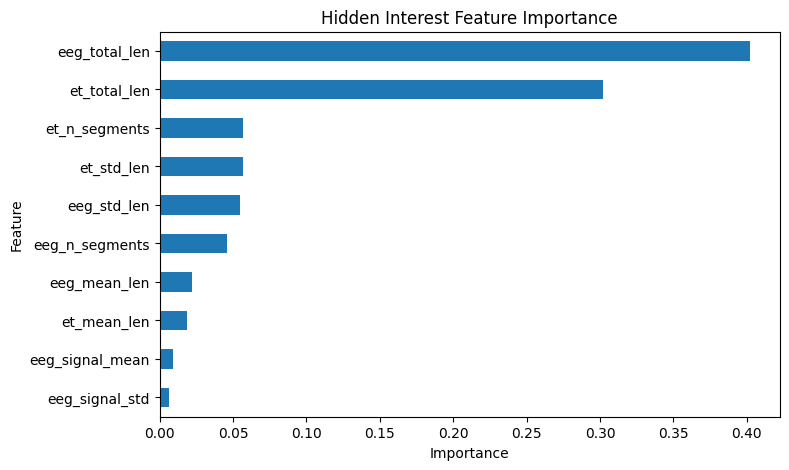

In [24]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Hidden Interest ----------------
y_hidden = df["hidden_interest"]

rf_hidden = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf_hidden.fit(X, y_hidden)

hidden_importance = pd.Series(
    rf_hidden.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop Hidden Interest Features:\n")
print(hidden_importance)

# plot
plt.figure(figsize=(8,5))

hidden_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Hidden Interest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


Top Cognitive Overload Features:

eeg_signal_std         0.331256
eeg_n_segments         0.196050
et_n_segments          0.180069
eeg_signal_abs_mean    0.143109
eeg_std_len            0.029908
eeg_mean_len           0.024612
et_mean_len            0.024217
et_std_len             0.021069
eeg_total_len          0.016462
et_total_len           0.013833
et_signal_std          0.004920
eeg_signal_mean        0.004052
et_signal_abs_mean     0.004019
et_signal_mean         0.003585
product_num            0.001789
page                   0.001051
et_fs                  0.000000
eeg_fs                 0.000000
dtype: float64


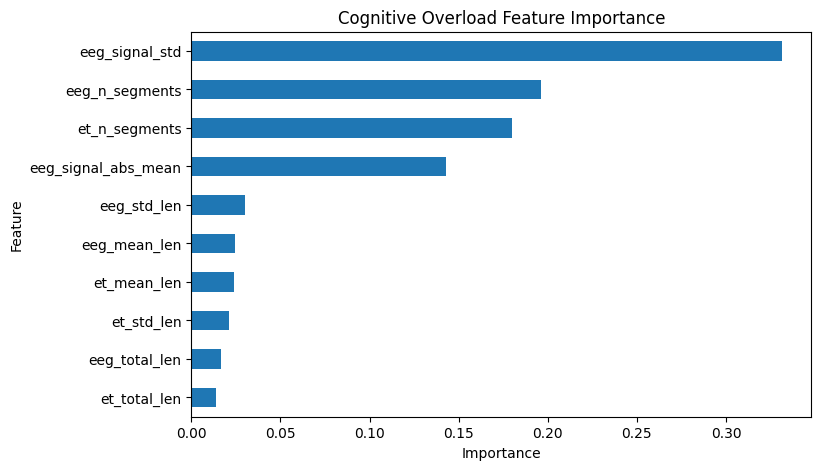

In [25]:
# ---------------- Cognitive Overload ----------------
y_overload = df["cognitive_overload"]

rf_overload = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf_overload.fit(X, y_overload)

overload_importance = pd.Series(
    rf_overload.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop Cognitive Overload Features:\n")
print(overload_importance)

# plot
plt.figure(figsize=(8,5))

overload_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Cognitive Overload Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


Top Decision Reversal Features:

et_duration_drop    0.187464
brain_drop          0.182115
engagement_drop     0.161032
late_buy_rate       0.071113
brain_std           0.066973
att_slope           0.065267
brain_slope         0.061030
att_std             0.057398
eeg_std_change      0.041561
et_segment_drop     0.032970
et_std_change       0.021054
late_brain          0.018038
early_brain         0.017063
early_attention     0.010847
late_attention      0.006076
dtype: float64


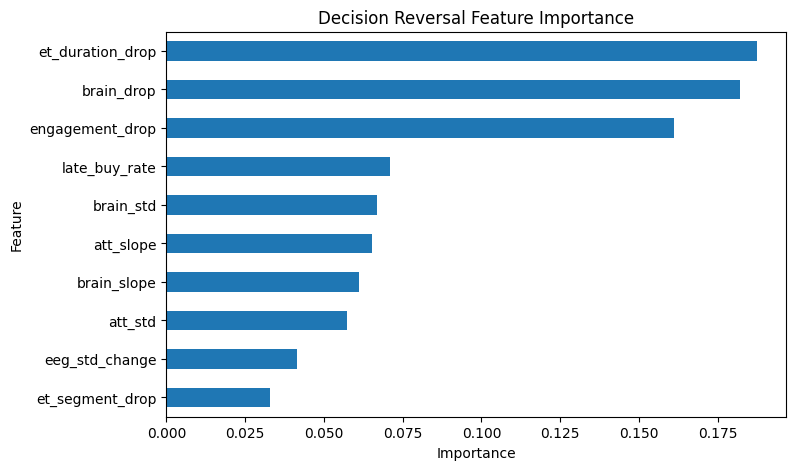

In [26]:
X_rev = rev_ml_df.drop(
    columns=["subject_id", "decision_reversal"]
).fillna(0)

y_rev = rev_ml_df["decision_reversal"]

rf_rev = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

rf_rev.fit(X_rev, y_rev)

rev_importance = pd.Series(
    rf_rev.feature_importances_,
    index=X_rev.columns
).sort_values(ascending=False)

print("\nTop Decision Reversal Features:\n")
print(rev_importance)

# plot
plt.figure(figsize=(8,5))

rev_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Decision Reversal Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [27]:
print("Best Hidden Interest model:")
display(hidden_results.head(1))

print("Best Cognitive Overload model:")
display(overload_results.head(1))

print("Best Decision Reversal model:")
display(reversal_results.head(1))

Best Hidden Interest model:


,model,accuracy,precision_1,recall_1,f1_1
0,MLP,0.909917,0.680672,0.830769,0.748268


Best Cognitive Overload model:


,model,accuracy,precision_1,recall_1,f1_1
1,1D CNN,0.958678,0.837079,0.876471,0.856322


Best Decision Reversal model:


,model,threshold,accuracy,precision_1,recall_1,f1_1
1,1D CNN,0.6,0.952381,1.0,0.6,0.75


EEG vs Decision Change graph

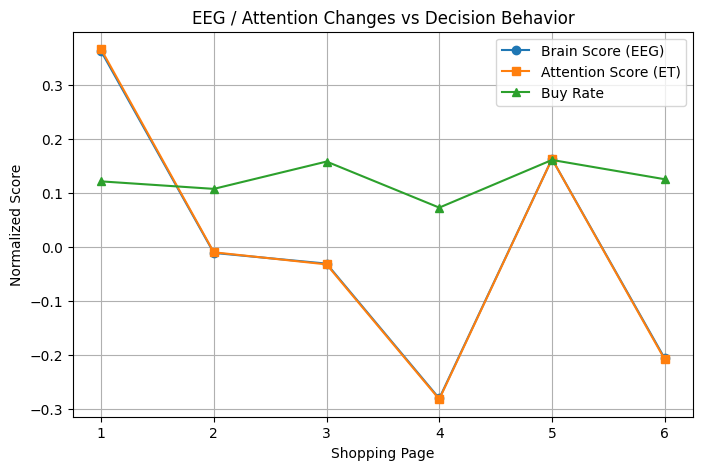

In [28]:
import matplotlib.pyplot as plt

# average per page
page_summary = df.groupby("page").agg({
    "brain_score": "mean",
    "attention_score": "mean",
    "buy_label": "mean"
}).reset_index()

plt.figure(figsize=(8,5))

plt.plot(page_summary["page"],
         page_summary["brain_score"],
         marker='o',
         label="Brain Score (EEG)")

plt.plot(page_summary["page"],
         page_summary["attention_score"],
         marker='s',
         label="Attention Score (ET)")

plt.plot(page_summary["page"],
         page_summary["buy_label"],
         marker='^',
         label="Buy Rate")

plt.xlabel("Shopping Page")
plt.ylabel("Normalized Score")
plt.title("EEG / Attention Changes vs Decision Behavior")

plt.legend()
plt.grid(True)
plt.show()

EEG instability for overload

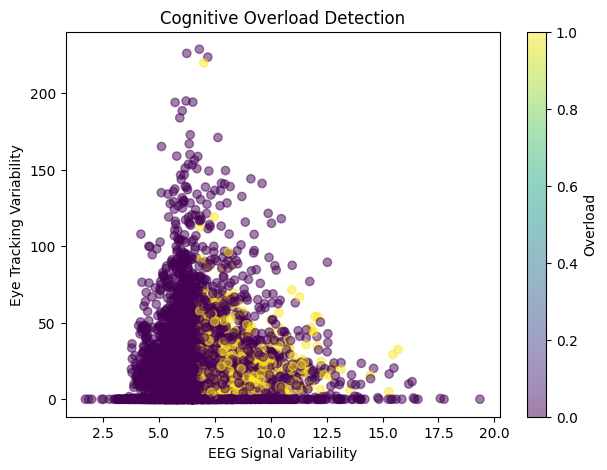

In [29]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["eeg_signal_std"],
    df["et_std_len"],
    c=df["cognitive_overload"],
    cmap="viridis",
    alpha=0.5
)

plt.xlabel("EEG Signal Variability")
plt.ylabel("Eye Tracking Variability")
plt.title("Cognitive Overload Detection")

plt.colorbar(label="Overload")
plt.show()

Hidden Interest EEG visualization

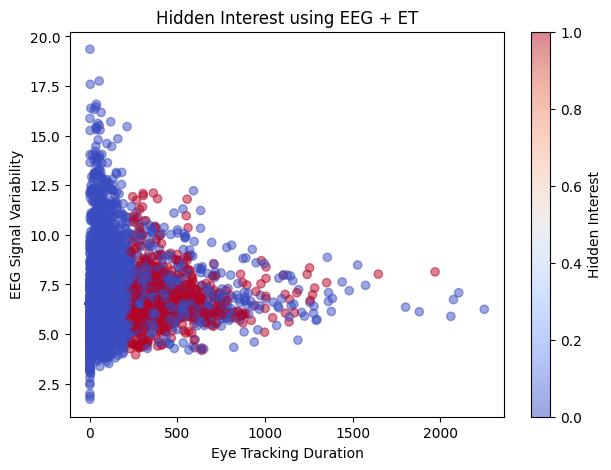

In [30]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["et_total_len"],
    df["eeg_signal_std"],
    c=df["hidden_interest"],
    cmap="coolwarm",
    alpha=0.5
)

plt.xlabel("Eye Tracking Duration")
plt.ylabel("EEG Signal Variability")
plt.title("Hidden Interest using EEG + ET")

plt.colorbar(label="Hidden Interest")
plt.show()

## Actual vs Predicted Comparison
This section compares the rule-based actual labels with model predicted labels for all three problem statements using clean bar graphs and confusion matrices.


,Task,Best Model,Accuracy
0,Hidden Interest,MLP,0.909917
1,Cognitive Overload,1D CNN,0.958678
2,Decision Reversal,1D CNN,0.952381


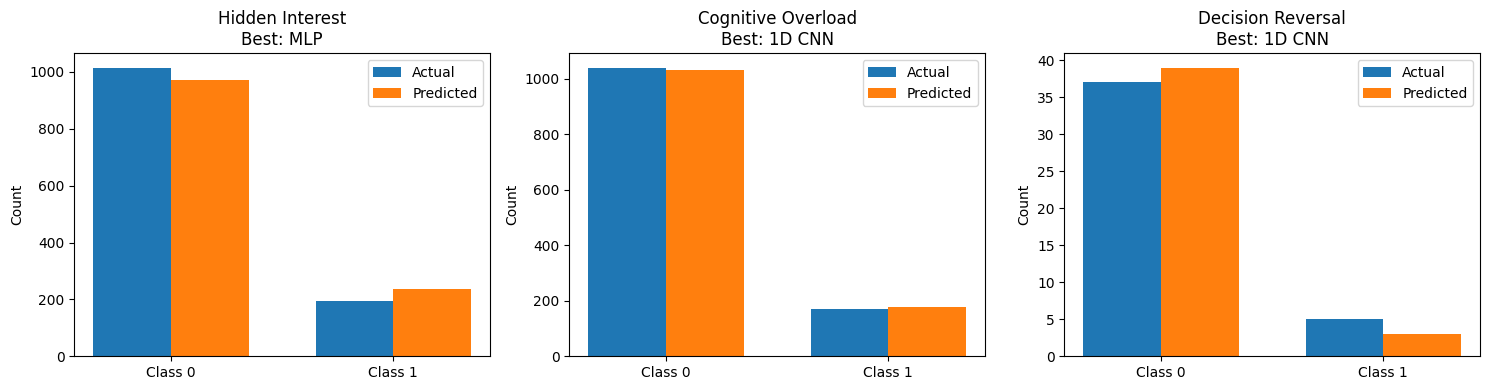

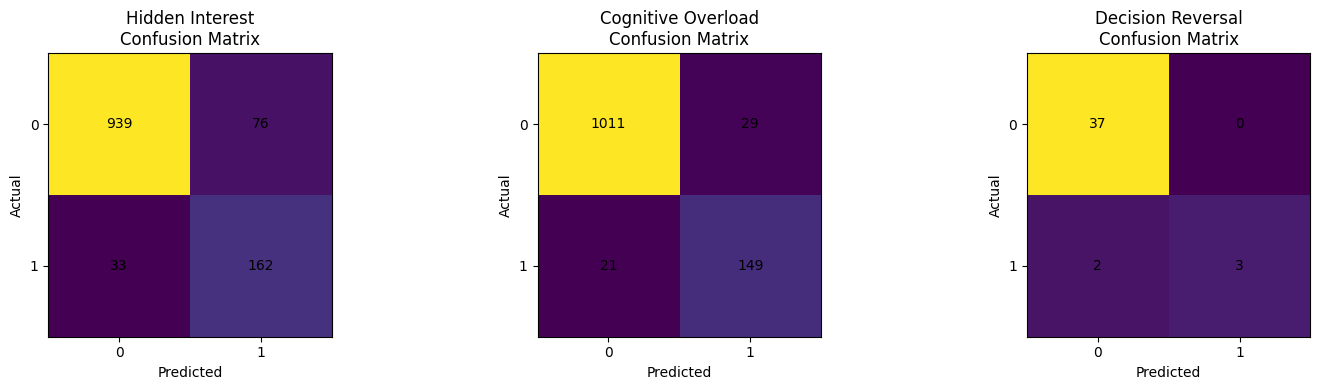


Hidden Interest - Best Model: MLP
Accuracy: 0.9099173553719008
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1015
           1       0.68      0.83      0.75       195

    accuracy                           0.91      1210
   macro avg       0.82      0.88      0.85      1210
weighted avg       0.92      0.91      0.91      1210



,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,1,1



Cognitive Overload - Best Model: 1D CNN
Accuracy: 0.9586776859504132
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1040
           1       0.84      0.88      0.86       170

    accuracy                           0.96      1210
   macro avg       0.91      0.92      0.92      1210
weighted avg       0.96      0.96      0.96      1210



,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,1,1
9,0,0



Decision Reversal - Best Model: 1D CNN
Accuracy: 0.9523809523809523
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        37
           1       1.00      0.60      0.75         5

    accuracy                           0.95        42
   macro avg       0.97      0.80      0.86        42
weighted avg       0.95      0.95      0.95        42



,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Collect best model predictions
# -----------------------------
best_hidden = hidden_results.iloc[0]["model"]
best_overload = overload_results.iloc[0]["model"]
best_reversal = reversal_results.iloc[0]["model"]

y_actual_hidden = hidden_saved[best_hidden]["actual"]
y_pred_hidden = hidden_saved[best_hidden]["predicted"]

y_actual_overload = overload_saved[best_overload]["actual"]
y_pred_overload = overload_saved[best_overload]["predicted"]

y_actual_reversal = reversal_saved[best_reversal]["actual"]
y_pred_reversal = reversal_saved[best_reversal]["predicted"]

comparison_sets = {
    "Hidden Interest": (y_actual_hidden, y_pred_hidden, best_hidden),
    "Cognitive Overload": (y_actual_overload, y_pred_overload, best_overload),
    "Decision Reversal": (y_actual_reversal, y_pred_reversal, best_reversal)
}

# -----------------------------
# Accuracy summary table
# -----------------------------
summary_rows = []

for task, (actual, predicted, model_name) in comparison_sets.items():
    summary_rows.append({
        "Task": task,
        "Best Model": model_name,
        "Accuracy": accuracy_score(actual, predicted)
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# -----------------------------
# Actual vs Predicted count bars
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (task, (actual, predicted, model_name)) in zip(axes, comparison_sets.items()):
    actual_counts = pd.Series(actual).value_counts().reindex([0, 1], fill_value=0)
    pred_counts = pd.Series(predicted).value_counts().reindex([0, 1], fill_value=0)

    x = np.arange(2)
    width = 0.35

    ax.bar(x - width/2, actual_counts.values, width, label="Actual")
    ax.bar(x + width/2, pred_counts.values, width, label="Predicted")

    ax.set_title(f"{task}\nBest: {model_name}")
    ax.set_xticks(x)
    ax.set_xticklabels(["Class 0", "Class 1"])
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# Confusion matrices
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (task, (actual, predicted, model_name)) in zip(axes, comparison_sets.items()):
    cm = confusion_matrix(actual, predicted, labels=[0, 1])

    im = ax.imshow(cm)
    ax.set_title(f"{task}\nConfusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

# -----------------------------
# Small actual vs predicted samples table
# -----------------------------
for task, (actual, predicted, model_name) in comparison_sets.items():
    print(f"\n{task} - Best Model: {model_name}")
    print("Accuracy:", accuracy_score(actual, predicted))
    print(classification_report(actual, predicted, zero_division=0))

    display(pd.DataFrame({
        "Actual": actual,
        "Predicted": predicted
    }).head(20))

